# CROHME Colab One-Click Demo

This notebook runs the full MVP demo in one Colab session:

- base-model inference and evaluation on CROHME benchmark splits
- LoRA fine-tuning on the CROHME train split
- post-training evaluation on the same benchmark splits
- automatic per-experiment report figures
- cross-experiment comparison figures for report writing

The current code path supports `Qwen2-VL`, `Qwen2.5-VL`, and `Qwen3-VL` model IDs in the training and inference backends.

Method summary:

1. Clone the repo from `main`.
2. Install the Python dependencies.
3. Build Colab-safe configs for both pipelines.
4. Run `scripts/run_inference_pipeline.sh`.
5. Run `scripts/run_lora_pipeline.sh`.
6. Regenerate report visualizations with `scripts/run_report_visualization.sh`.

Use a GPU runtime before running the notebook.


In [ ]:
REPO_URL = "https://github.com/Zeric-li/HME.git"
WORKDIR = "/content/HME"

!rm -rf "$WORKDIR"
!git clone --depth 1 --branch main "$REPO_URL" "$WORKDIR"
%cd "$WORKDIR"

!python -m pip install -U pip
!pip install -r requirements.txt
!pip install -U "git+https://github.com/huggingface/transformers"

Cloning into '/content/HME'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 28 (delta 2), reused 15 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 22.53 KiB | 22.53 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/HME
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 85.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 197.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [qwen-vl-utils]
  Cloning https://github.com/huggingface/transformers to /tmp/pip-req-build-j3xrlv_2
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers /tmp/pip-req-build-j3xrlv_2
  Resolved https://github.com/huggingface/transformers to commit f38d6639fa6b

In [ ]:
from pathlib import Path

OUTPUT_ROOT = "/content/outputs"
RUN_BASELINE = True
RUN_LORA = True

INFERENCE_CONFIG = {
    'pipeline_type': 'inference_only',
    'model_id': 'Qwen/Qwen3-VL-4B-Instruct',
    'output_dir': str(Path(OUTPUT_ROOT) / 'qwen3vl-crohme-base'),
    'run_name': 'qwen3vl-crohme-base',
    'eval_dataset_id': 'Neeze/CROHME-full',
    'eval_splits': ['2014', '2016', '2019'],
    'max_eval_samples': None,
    'eval_batch_size': 1,
    'seed': 42,
    'system_prompt': 'You are a precise handwritten mathematical expression recognition (HMER) system. Extract and Print the expression of the formula in the image using LaTeX format. ',
    'user_prompt': 'Do not wrap the answer in markdown or LaTeX fences. Do not add any text, spaces before or after.',
    'min_pixels': 200704,
    'max_pixels': 602112,
    'max_new_tokens': 128,
    'torch_dtype': 'bfloat16',
    'attn_implementation': 'flash_attention_2',
}

LORA_CONFIG = {
    'pipeline_type': 'lora_train_eval',
    'model_id': 'Qwen/Qwen3-VL-4B-Instruct',
    'output_dir': str(Path(OUTPUT_ROOT) / 'qwen3vl-crohme-lora'),
    'run_name': 'qwen3vl-crohme-lora',
    'train_dataset_id': 'Neeze/CROHME-full',
    'train_split': 'train',
    'eval_dataset_id': 'Neeze/CROHME-full',
    'train_eval_split': '2014',
    'eval_splits': ['2014', '2016', '2019'],
    'max_train_samples': None,
    'max_eval_samples': None,
    'eval_batch_size': 1,
    'shuffle_train': True,
    'seed': 42,
    'system_prompt': 'You are a precise handwritten mathematical expression recognition (HMER) system. Extract and Print the expression of the formula in the image using LaTeX format. ',
    'user_prompt': 'Do not wrap the answer in markdown or LaTeX fences. Do not add any text, spaces before or after.',
    'min_pixels': 200704,
    'max_pixels': 602112,
    'max_seq_length': 1024,
    'max_new_tokens': 128,
    'torch_dtype': 'bfloat16',
    'attn_implementation': 'flash_attention_2',
    'gradient_checkpointing': True,
    'per_device_train_batch_size': 2,
    'per_device_eval_batch_size': 1,
    'gradient_accumulation_steps': 8,
    'num_train_epochs': 2,
    'learning_rate': 2.0e-4,
    'weight_decay': 0.0,
    'warmup_ratio': 0.03,
    'lr_scheduler_type': 'cosine',
    'logging_steps': 10,
    'save_steps': 200,
    'eval_steps': 200,
    'save_total_limit': 2,
    'lora_r': 16,
    'lora_alpha': 32,
    'lora_dropout': 0.05,
    'lora_bias': 'none',
    'lora_target_modules': ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    'report_to': 'none',
}

print('Loaded Colab demo configs:')
print('INFERENCE_CONFIG:')
print(INFERENCE_CONFIG)
print('\nLORA_CONFIG:')
print(LORA_CONFIG)

Loaded Colab demo configs:
INFERENCE_CONFIG:
{'pipeline_type': 'inference_only', 'model_id': 'Qwen/Qwen3-VL-4B-Instruct', 'output_dir': '/content/outputs/qwen3vl-crohme-base', 'run_name': 'qwen3vl-crohme-base', 'eval_dataset_id': 'Neeze/CROHME-full', 'eval_splits': ['2014', '2016', '2019'], 'max_eval_samples': 32, 'eval_batch_size': 1, 'seed': 42, 'system_prompt': 'You are a precise handwritten mathematical expression recognition (HMER) system. Extract and Print the expression of the formula in the image using LaTeX format. ', 'user_prompt': 'Do not wrap the answer in markdown or LaTeX fences. Do not add any text, spaces before or after.', 'min_pixels': 200704, 'max_pixels': 602112, 'max_new_tokens': 128, 'torch_dtype': 'bfloat16', 'attn_implementation': 'flash_attention_2'}

LORA_CONFIG:
{'pipeline_type': 'lora_train_eval', 'model_id': 'Qwen/Qwen3-VL-4B-Instruct', 'output_dir': '/content/outputs/qwen3vl-crohme-lora', 'run_name': 'qwen3vl-crohme-lora', 'train_dataset_id': 'Neeze/CROHME

In [ ]:
from copy import deepcopy
from pathlib import Path
import importlib.util
import json
import torch
import yaml


def resolve_colab_runtime_overrides() -> dict:
    overrides = {
        'torch_dtype': 'float16',
        'attn_implementation': 'sdpa',
    }
    if not torch.cuda.is_available():
        return overrides

    major, _ = torch.cuda.get_device_capability()
    has_flash_attn = importlib.util.find_spec('flash_attn') is not None
    if major >= 8:
        overrides['torch_dtype'] = 'bfloat16'
    if has_flash_attn:
        overrides['attn_implementation'] = 'flash_attention_2'
    return overrides


def build_colab_config(task: str) -> Path:
    config = deepcopy(INFERENCE_CONFIG if task == 'inference_only' else LORA_CONFIG)

    config.update(resolve_colab_runtime_overrides())
    config['output_dir'] = str(config['output_dir'])

    if task == 'lora_train_eval':
        config['per_device_train_batch_size'] = 1
        config['per_device_eval_batch_size'] = 1
        config['gradient_accumulation_steps'] = max(int(config.get('gradient_accumulation_steps', 8)), 8)

    colab_config_path = Path('configs') / f'colab_{task}.yaml'
    with open(colab_config_path, 'w', encoding='utf-8') as handle:
        yaml.safe_dump(config, handle, sort_keys=False)

    return colab_config_path


config_paths = {}
if RUN_BASELINE:
    config_paths['inference_only'] = build_colab_config('inference_only')
if RUN_LORA:
    config_paths['lora_train_eval'] = build_colab_config('lora_train_eval')

print('Resolved runtime overrides:')
print(json.dumps(resolve_colab_runtime_overrides(), indent=2))

Prepared Colab configs:

=== inference_only :: configs/colab_inference_only.yaml ===
pipeline_type: inference_only
model_id: Qwen/Qwen3-VL-4B-Instruct
output_dir: /content/outputs/qwen3vl-crohme-base
run_name: qwen3vl-crohme-base
eval_dataset_id: Neeze/CROHME-full
eval_splits:
- '2014'
- '2016'
- '2019'
max_eval_samples: 32
eval_batch_size: 1
seed: 42
system_prompt: 'You are a precise handwritten mathematical expression recognition
  (HMER) system. Extract and Print the expression of the formula in the image using
  LaTeX format. '
user_prompt: Do not wrap the answer in markdown or LaTeX fences. Do not add any text,
  spaces before or after.
min_pixels: 200704
max_pixels: 602112
max_new_tokens: 128
torch_dtype: bfloat16
attn_implementation: sdpa


=== lora_train_eval :: configs/colab_lora_train_eval.yaml ===
pipeline_type: lora_train_eval
model_id: Qwen/Qwen3-VL-4B-Instruct
output_dir: /content/outputs/qwen3vl-crohme-lora
run_name: qwen3vl-crohme-lora
train_dataset_id: Neeze/CROHME-ful

In [4]:
from pathlib import Path
import json
import os
import subprocess
import time


def run_pipeline(task: str, config_path: Path) -> None:
    script_path = 'scripts/run_inference_pipeline.sh' if task == 'inference_only' else 'scripts/run_lora_pipeline.sh'
    env = os.environ.copy()
    env['PYTHONUNBUFFERED'] = '1'

    print(f'\n===== START {task} =====')
    start = time.time()
    process = subprocess.Popen(
        ['bash', script_path, str(config_path)],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )

    assert process.stdout is not None
    for line in process.stdout:
        print(line, end='')

    return_code = process.wait()
    duration_s = time.time() - start
    print(f'===== END {task} ({duration_s / 60.0:.1f} min) =====')
    if return_code != 0:
        raise subprocess.CalledProcessError(return_code, process.args)


for task, config_path in config_paths.items():
    run_pipeline(task, Path(config_path))

流式输出内容被截断，只能显示最后 5000 行内容。
 25%|██▌       | 251/986 [00:35<01:41,  7.21it/s]

 26%|██▌       | 252/986 [00:35<01:41,  7.22it/s]

 26%|██▌       | 253/986 [00:35<01:41,  7.23it/s]

 26%|██▌       | 254/986 [00:35<01:41,  7.22it/s]

 26%|██▌       | 255/986 [00:35<01:41,  7.22it/s]

 26%|██▌       | 256/986 [00:35<01:40,  7.24it/s]

 26%|██▌       | 257/986 [00:35<01:40,  7.23it/s]

 26%|██▌       | 258/986 [00:36<01:40,  7.23it/s]

 26%|██▋       | 259/986 [00:36<01:40,  7.22it/s]

 26%|██▋       | 260/986 [00:36<01:40,  7.24it/s]

 26%|██▋       | 261/986 [00:36<01:40,  7.24it/s]

 27%|██▋       | 262/986 [00:36<01:40,  7.23it/s]

 27%|██▋       | 263/986 [00:36<01:40,  7.23it/s]

 27%|██▋       | 264/986 [00:36<01:39,  7.23it/s]

 27%|██▋       | 265/986 [00:37<01:39,  7.23it/s]

 27%|██▋       | 266/986 [00:37<01:40,  7.15it/s]

 27%|██▋       | 267/986 [00:37<01:40,  7.17it/s]

 27%|██▋       | 268/986 [00:37<01:40,  7.13it/s]

 27%|██▋       | 269/986 [00:37<01:40,  7.16it/s]

 27%


=== inference_only overall metrics ===
{
  "num_splits": 3,
  "num_samples": 3332,
  "evaluated_splits": [
    "2014",
    "2016",
    "2019"
  ],
  "exact_match_rate": 0.3895558223289316,
  "avg_cer": 0.220227613420527,
  "avg_edit_score": 0.8244777030480059,
  "avg_bleu4": 0.6359743489259657,
  "avg_latency_s": 0.8255531240900339
}

[inference_only] cer_distribution.png


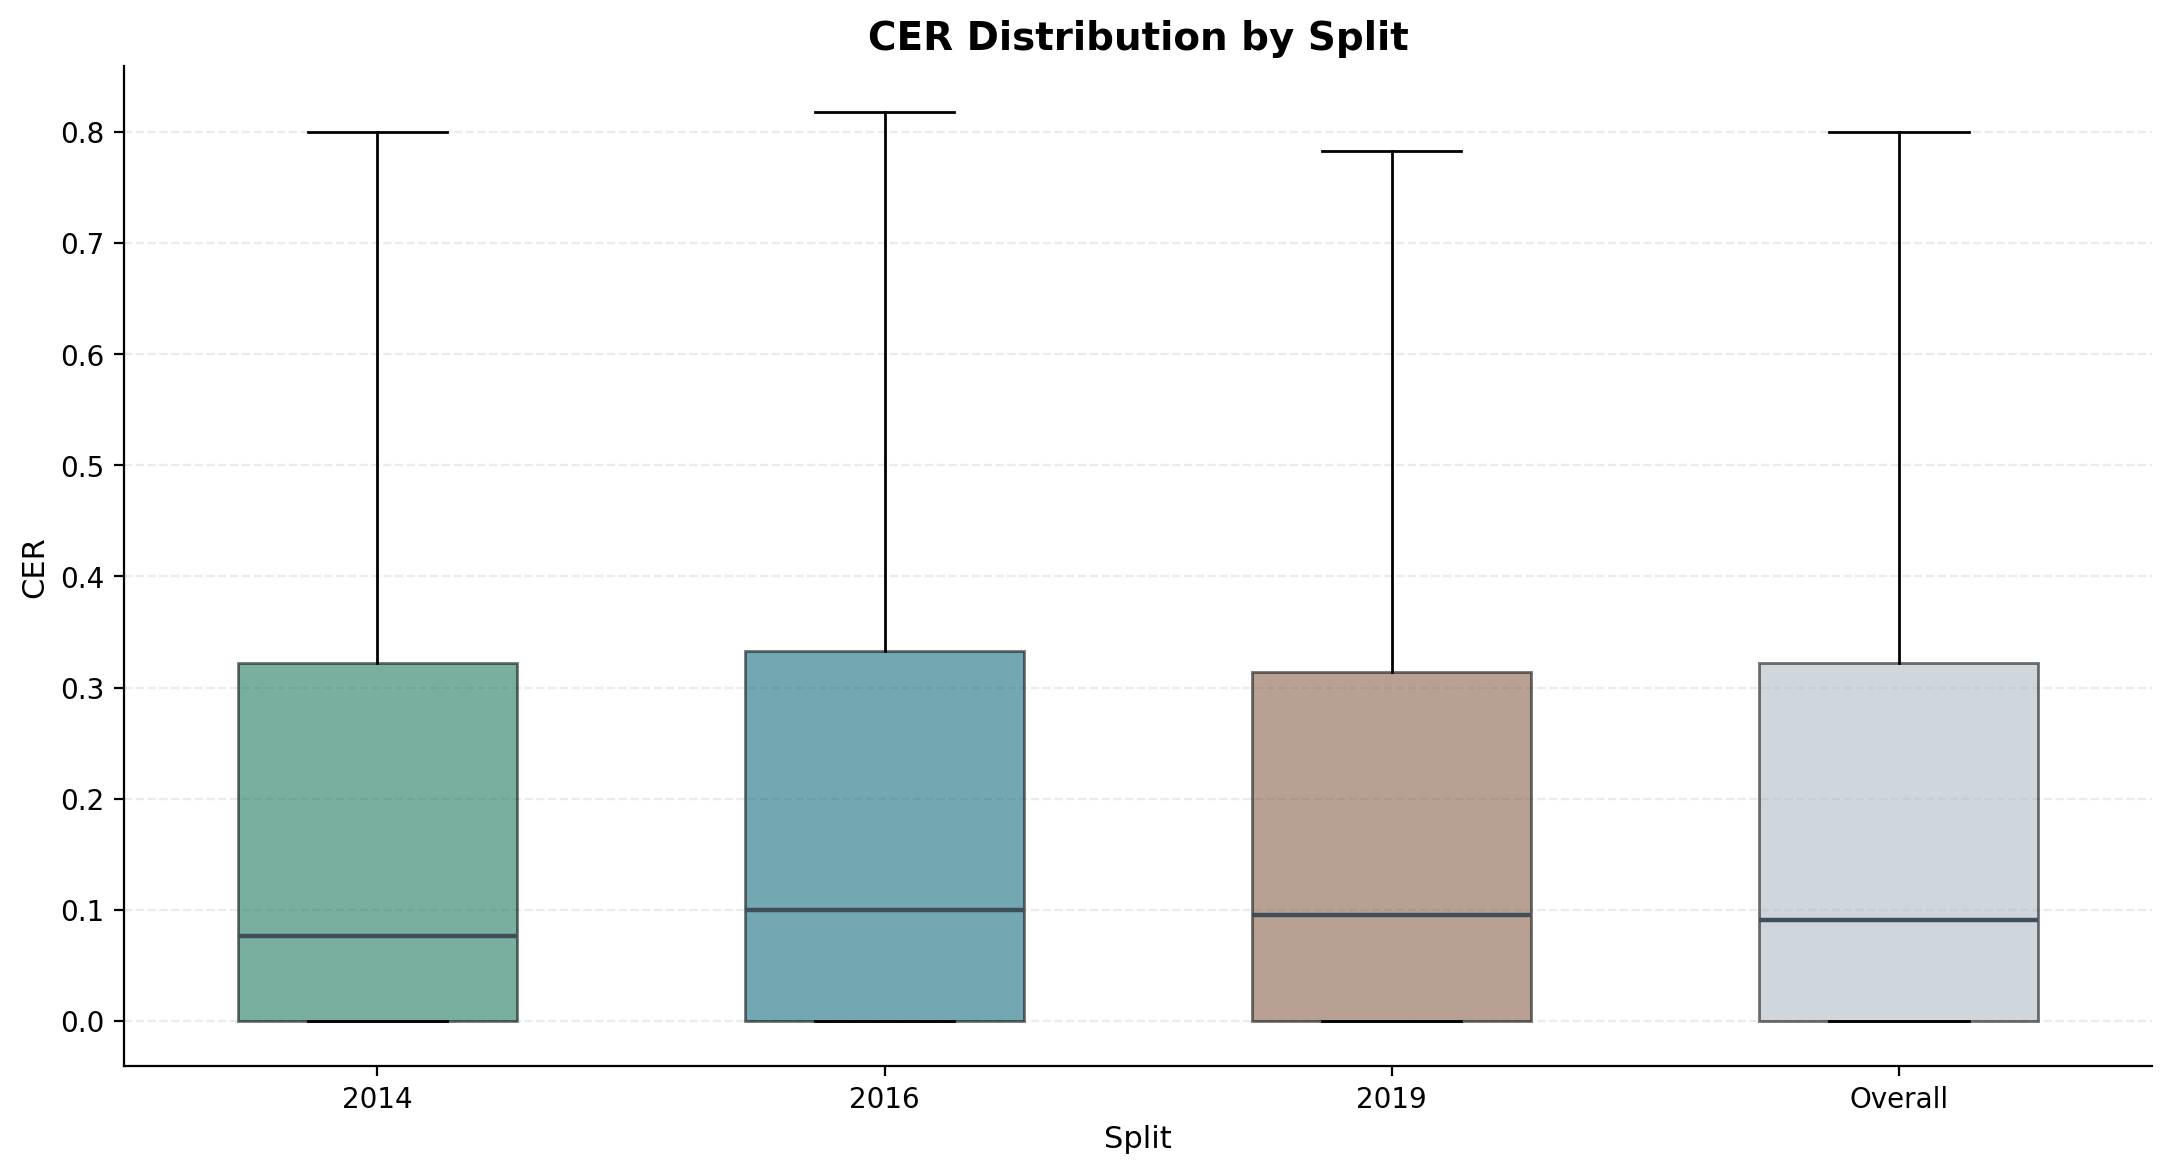


[inference_only] error_bucket_profile.png


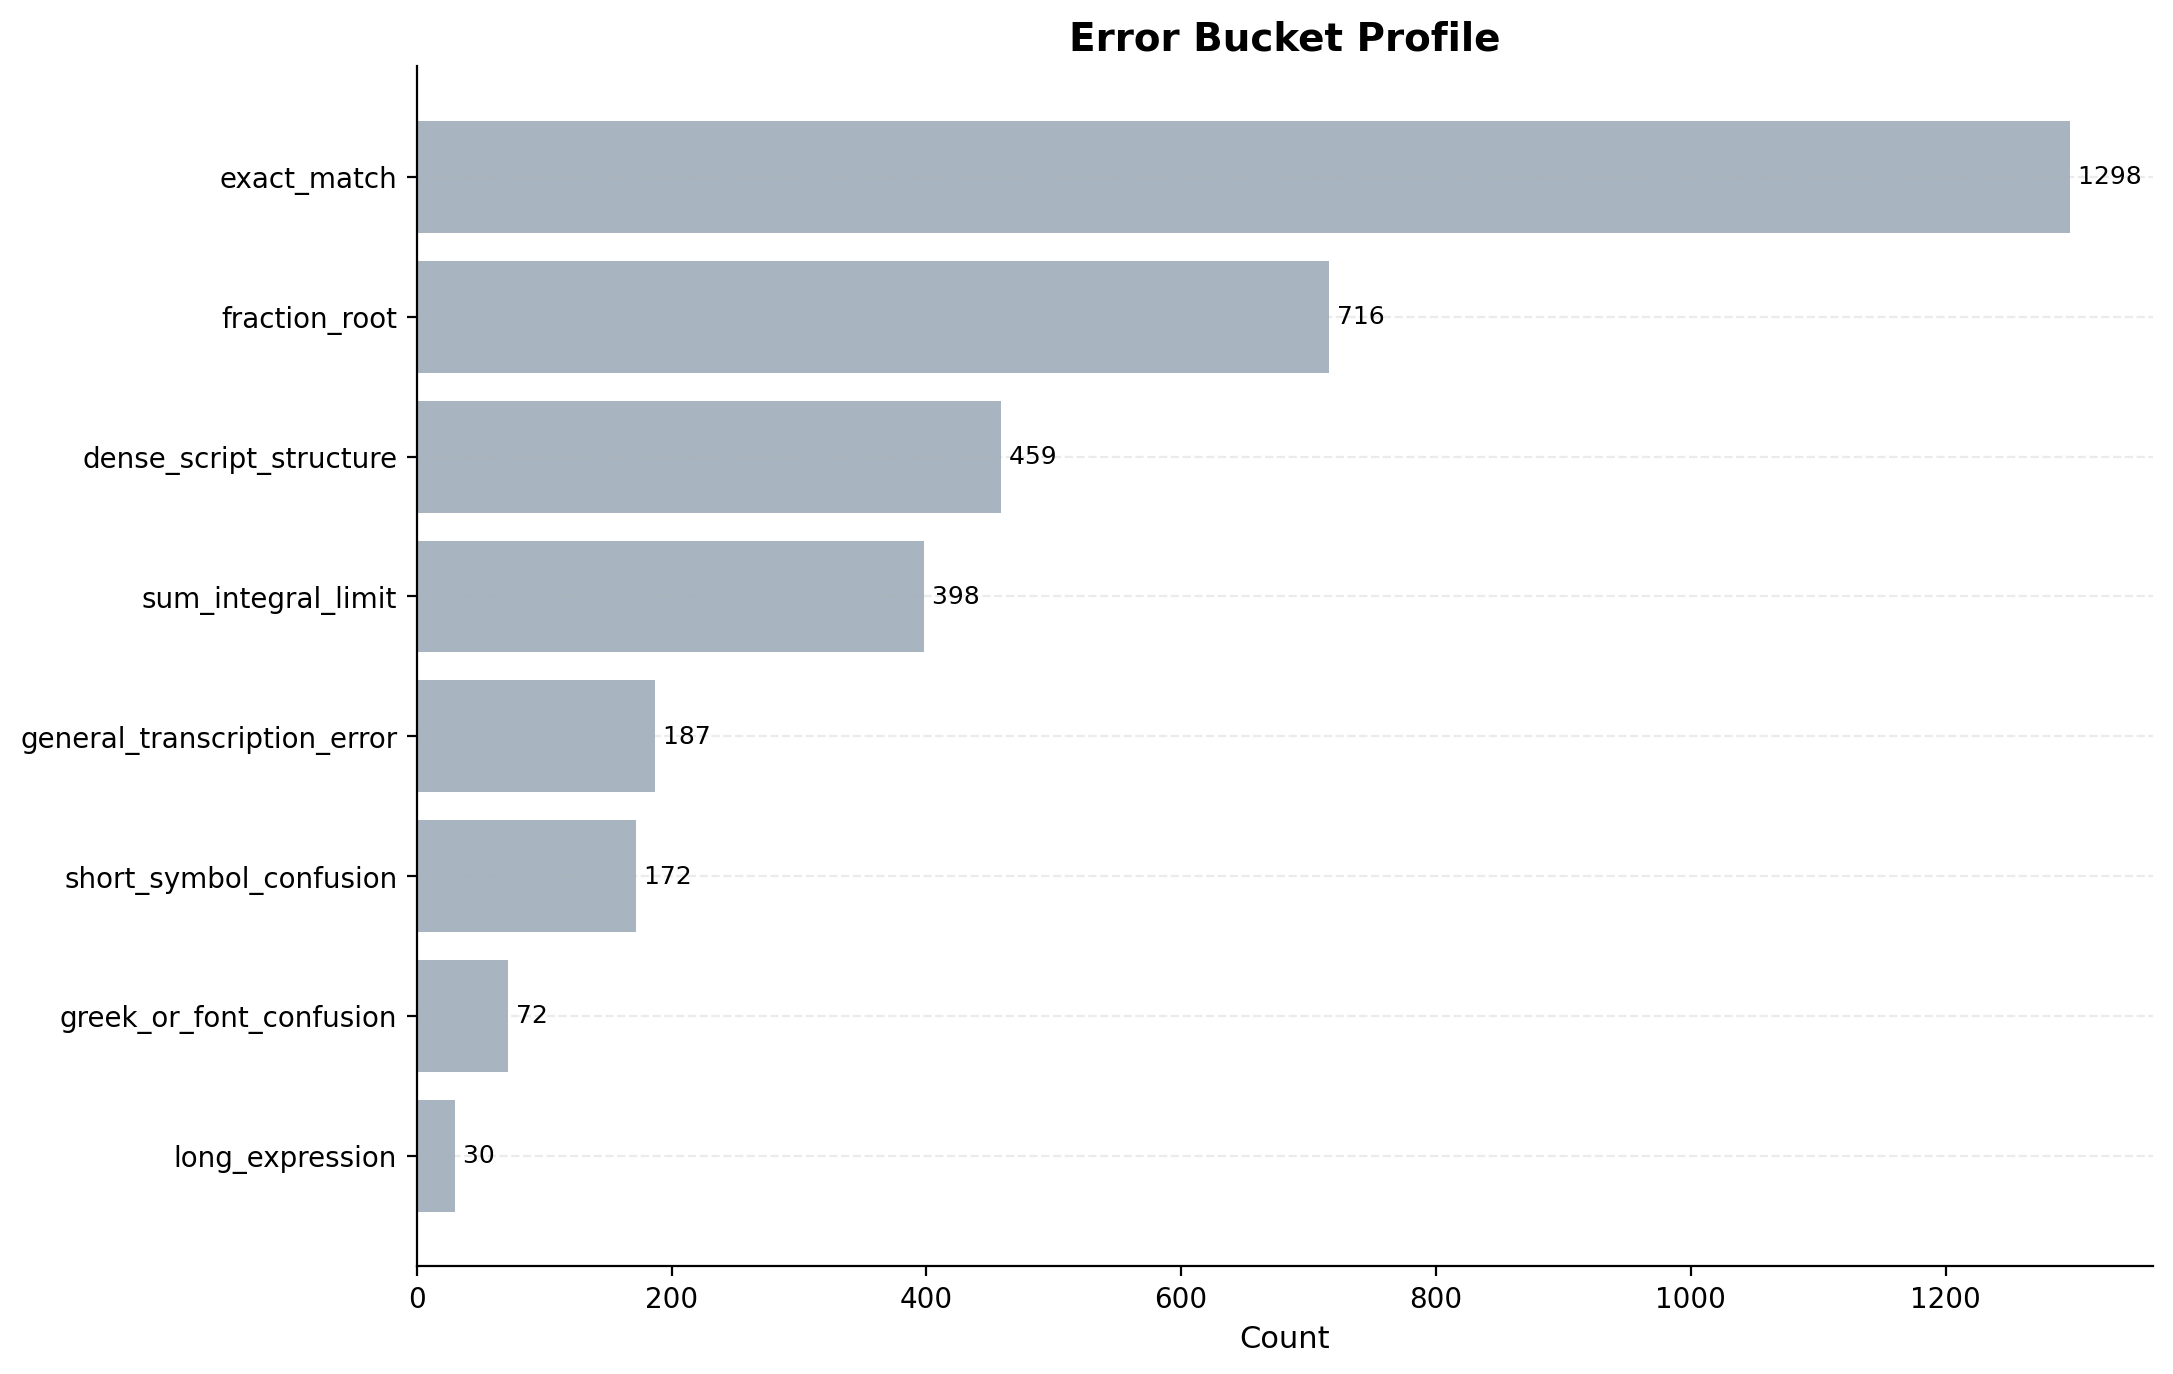


[inference_only] per_split_metrics.png


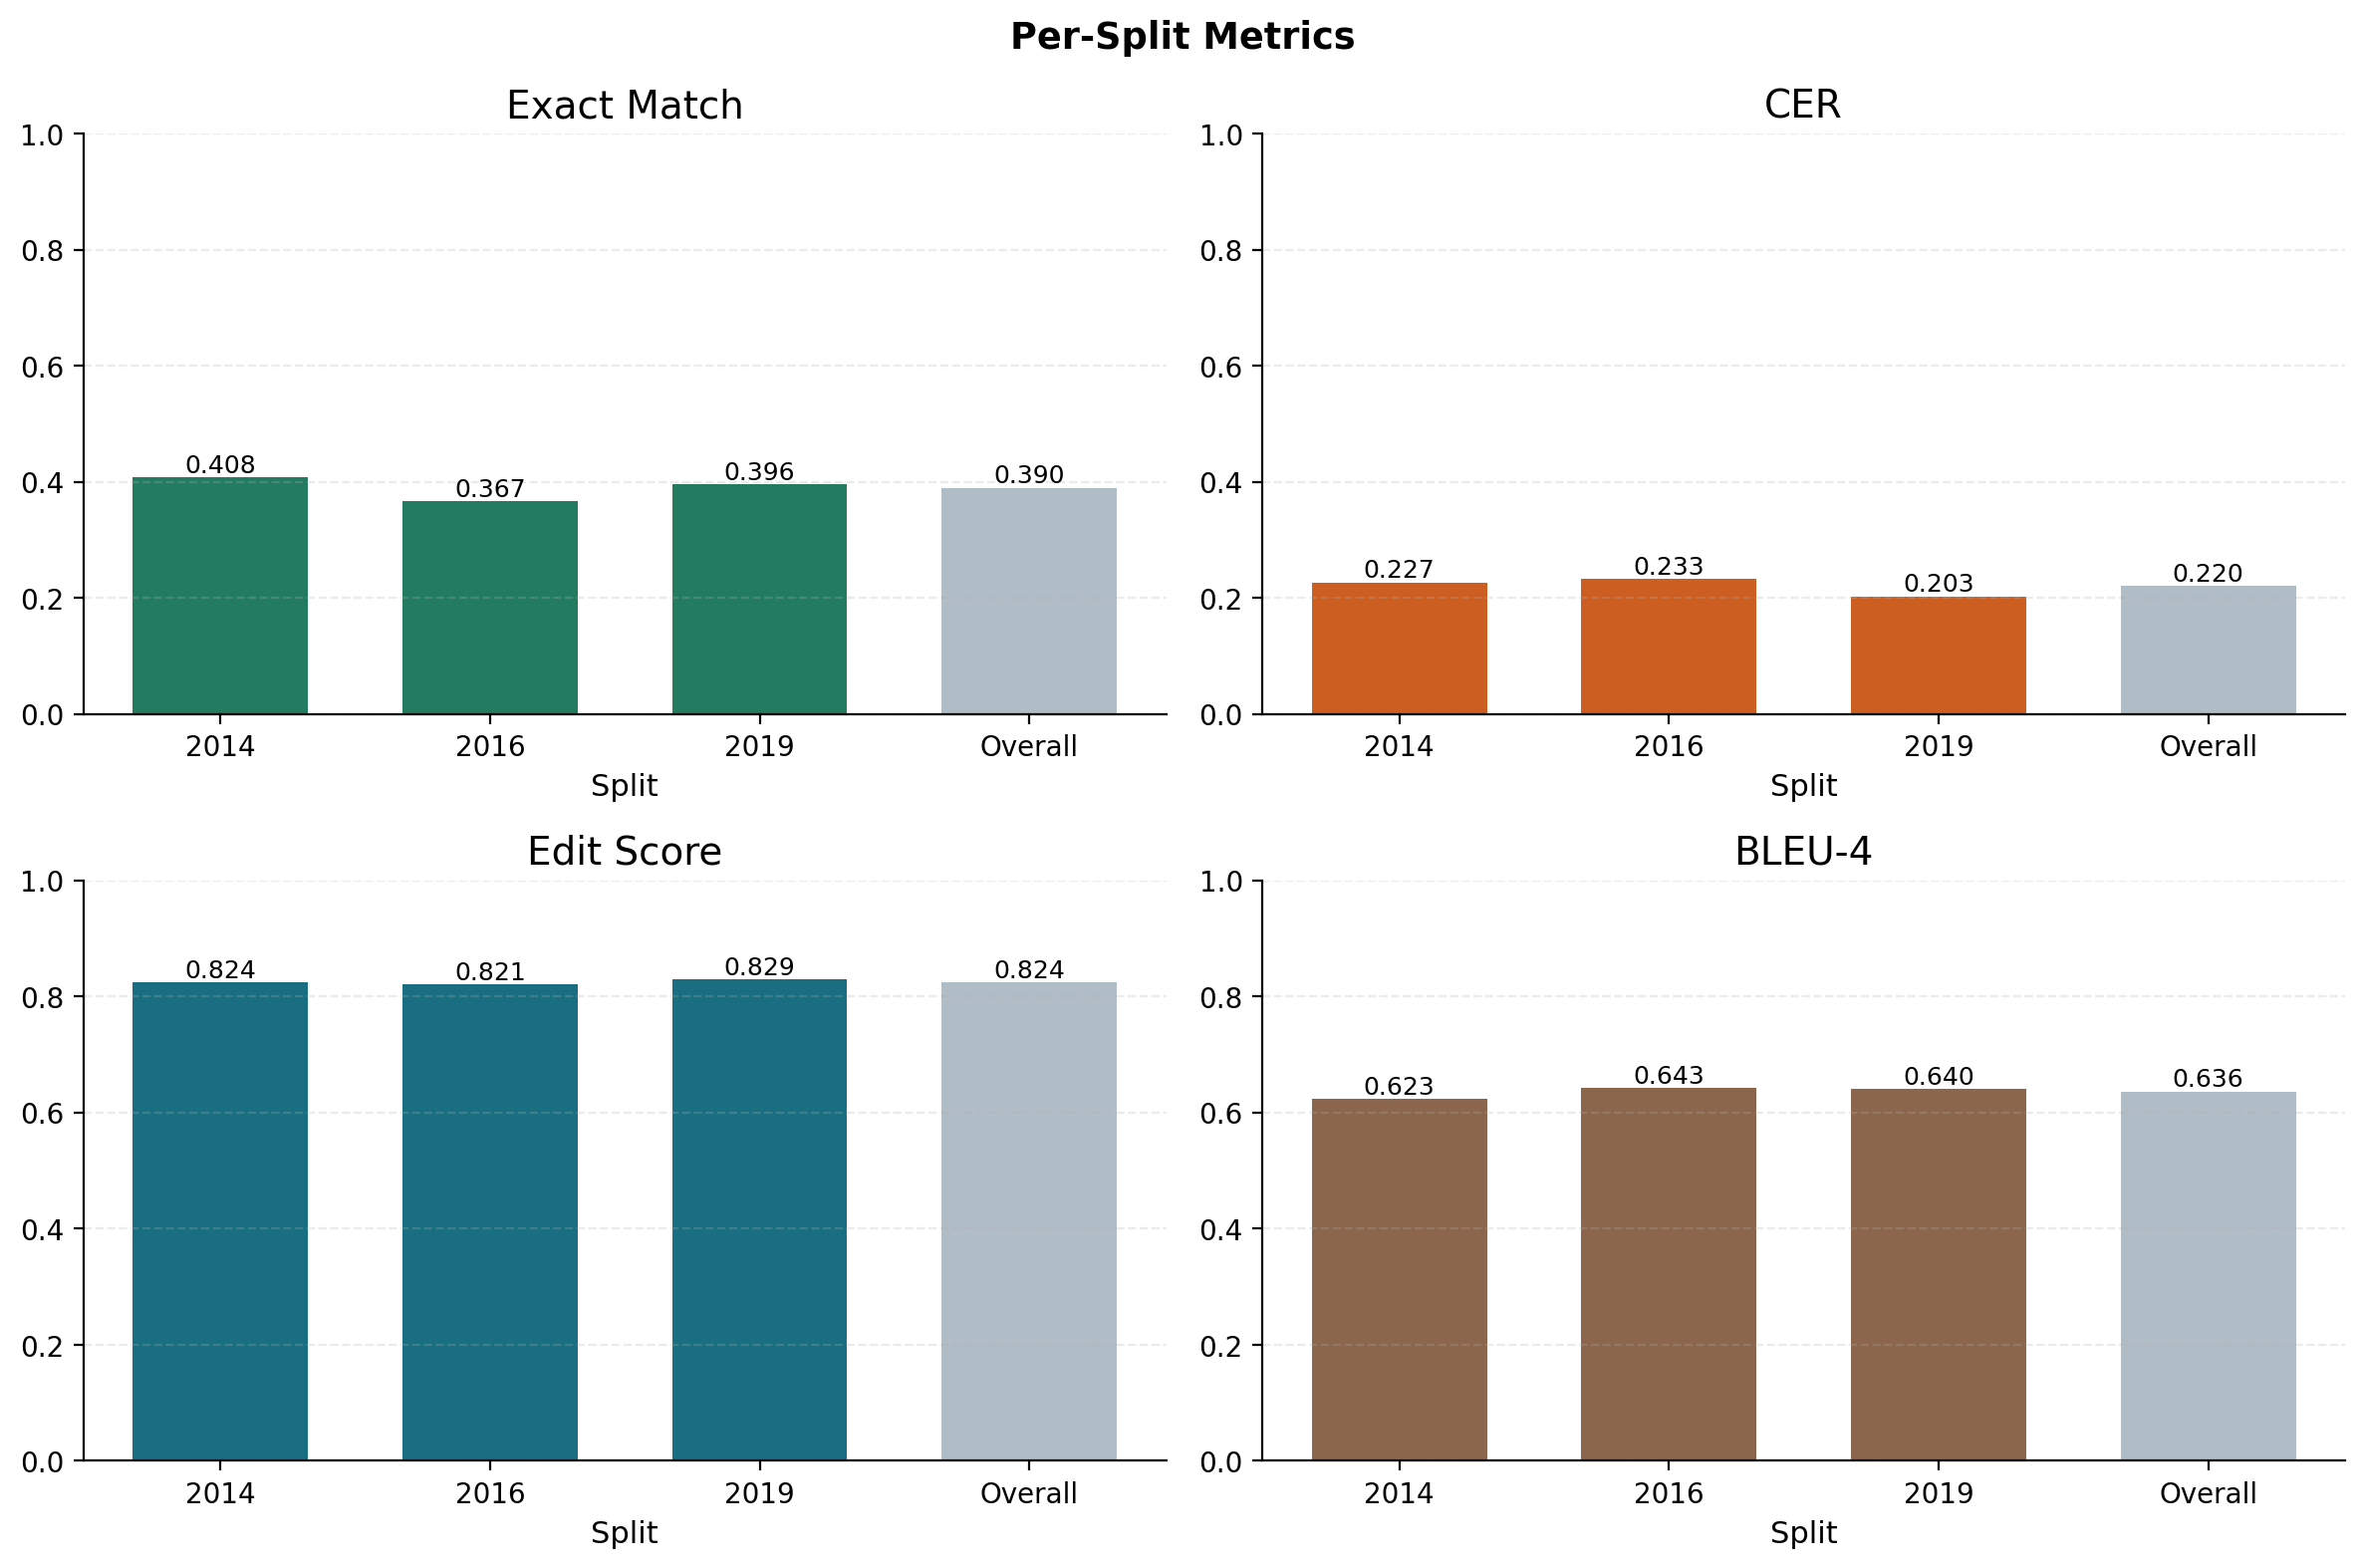


=== lora_train_eval overall metrics ===
{
  "num_splits": 3,
  "num_samples": 3332,
  "evaluated_splits": [
    "2014",
    "2016",
    "2019"
  ],
  "exact_match_rate": 0.6431572629051621,
  "avg_cer": 0.0900631593350957,
  "avg_edit_score": 0.9265702398014718,
  "avg_bleu4": 0.7608451923130601,
  "avg_latency_s": 1.7212250372758167
}

[lora_train_eval] cer_distribution.png


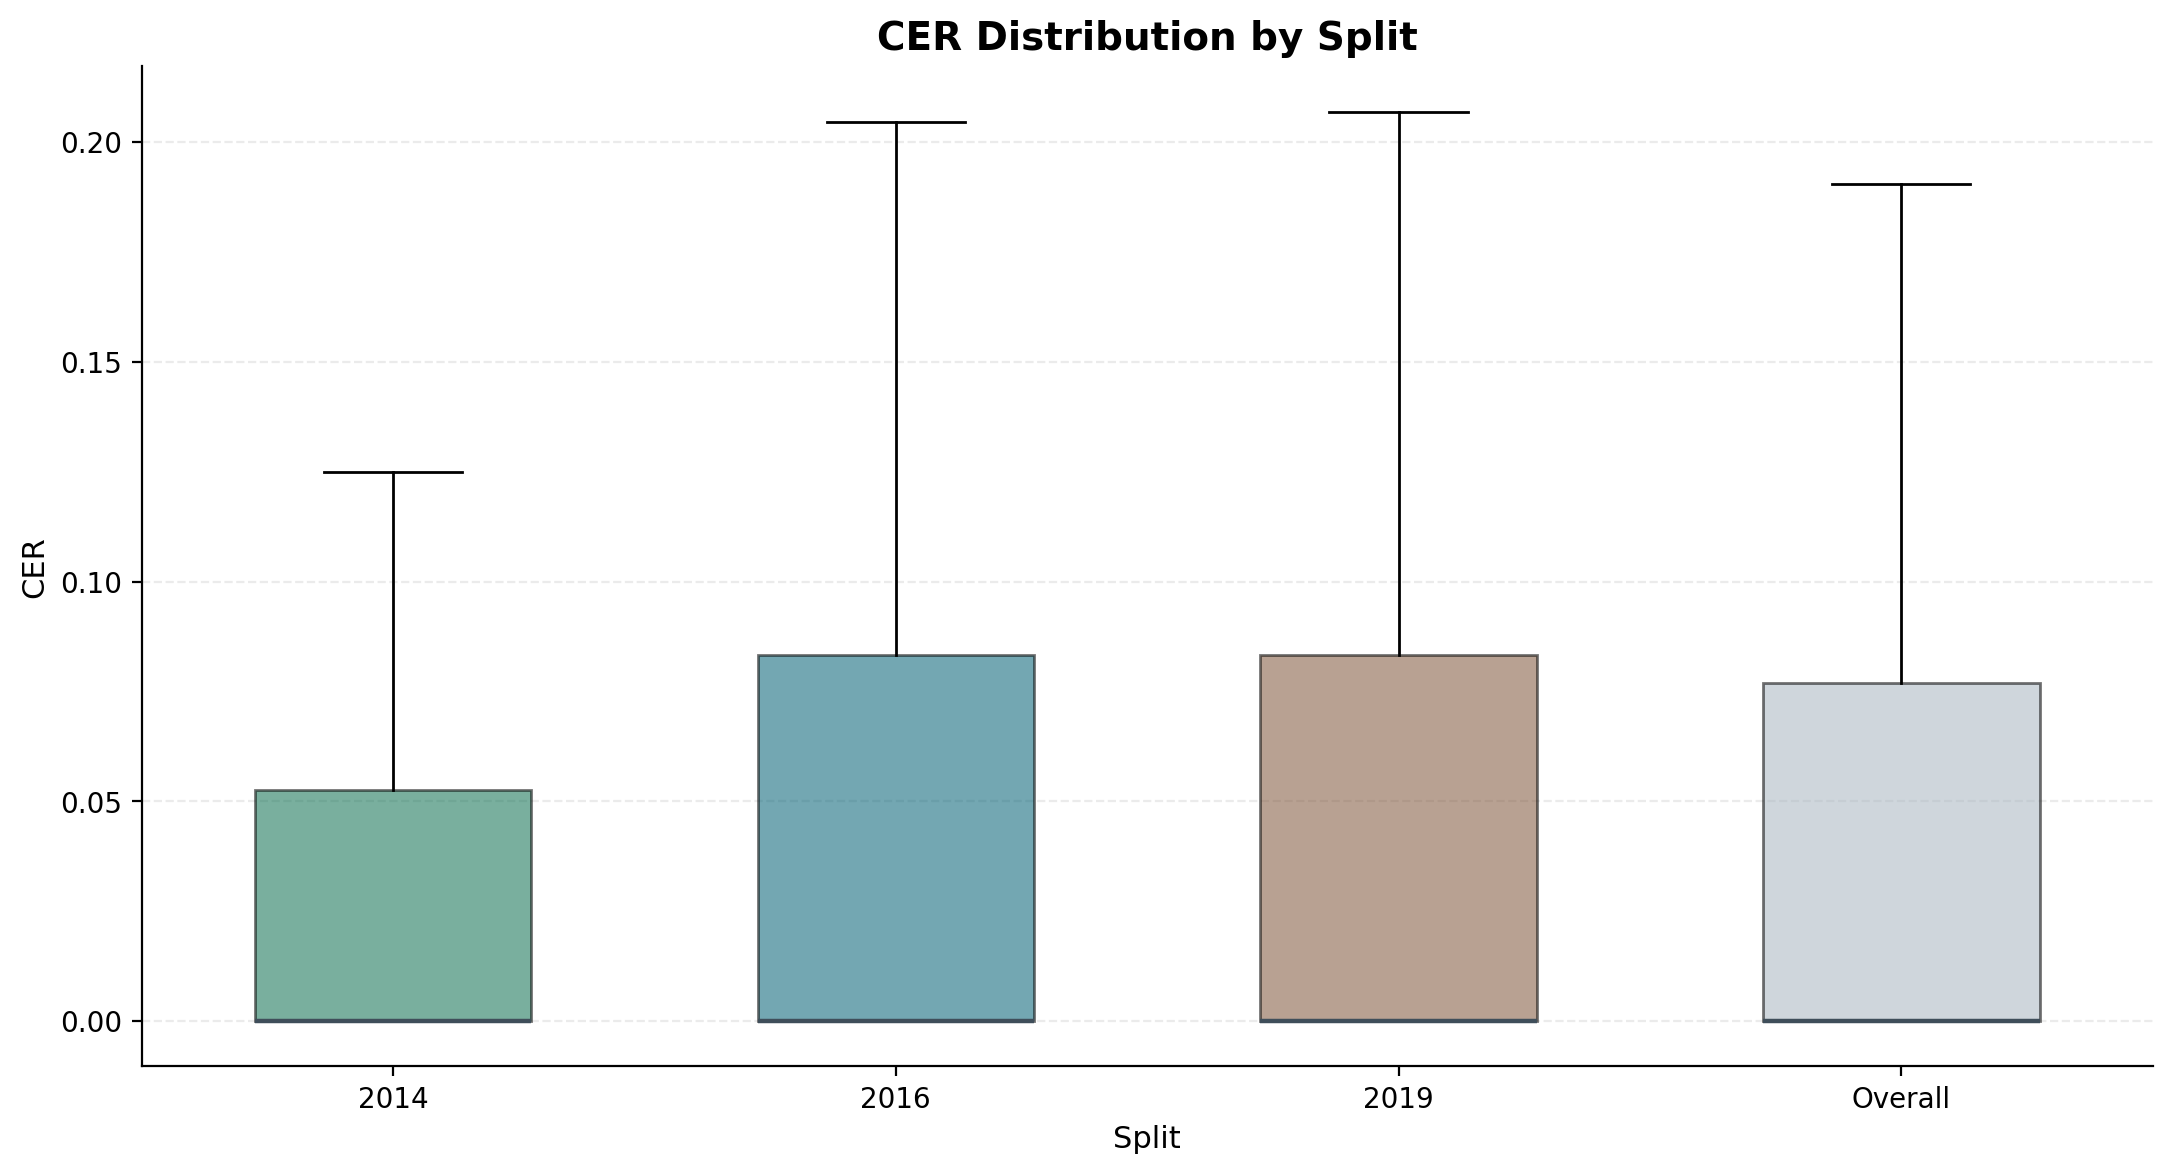


[lora_train_eval] error_bucket_profile.png


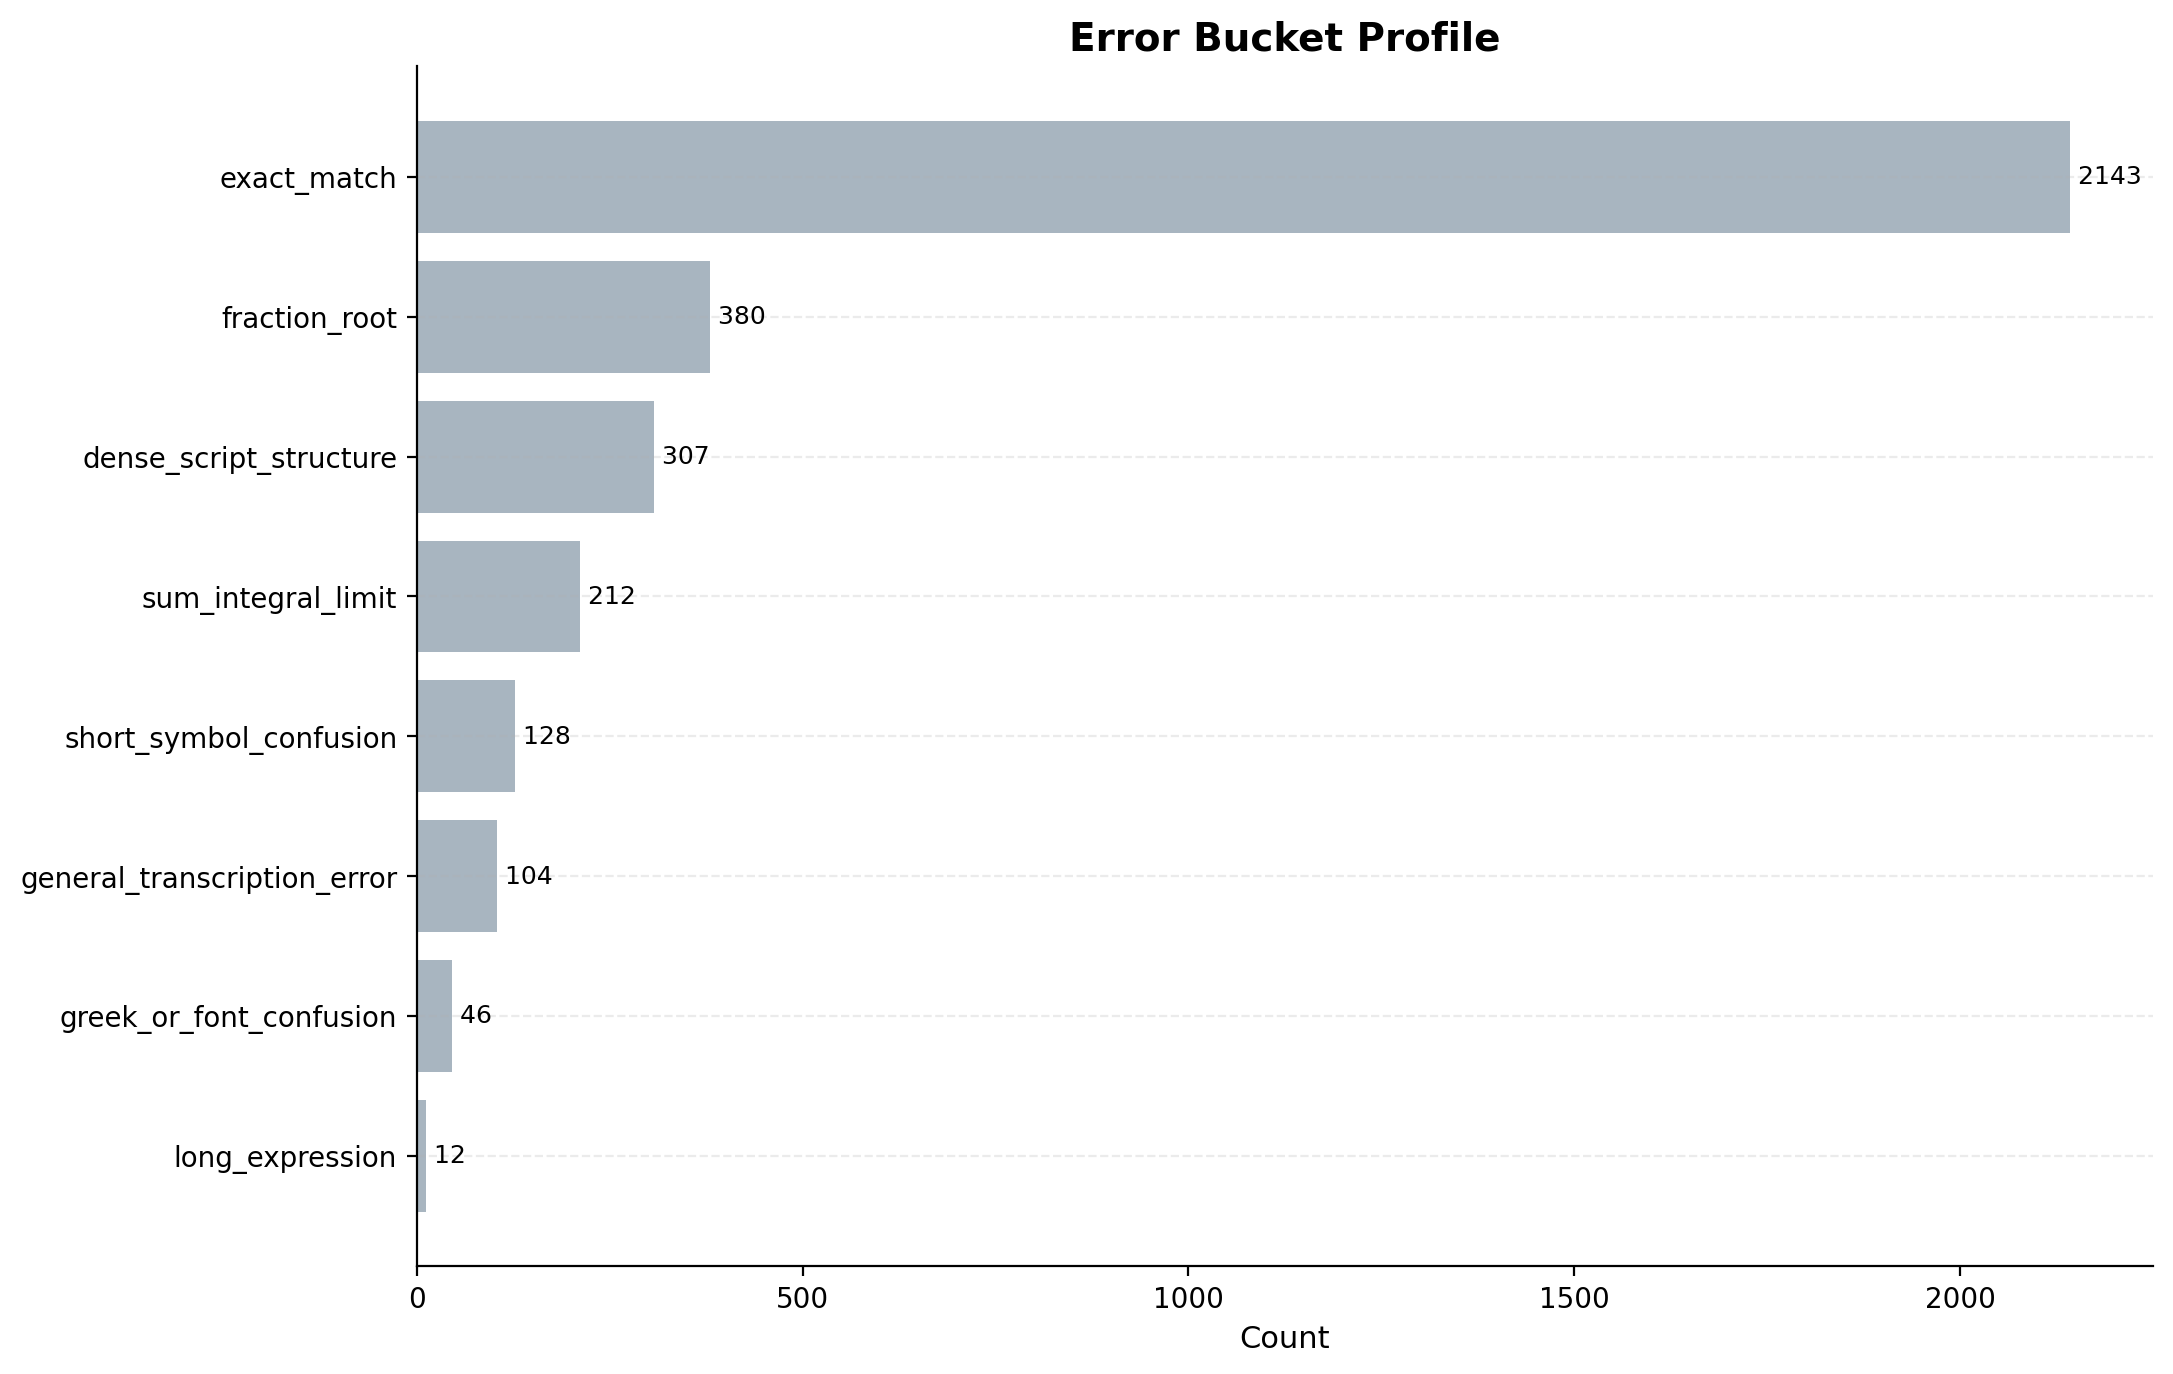


[lora_train_eval] per_split_metrics.png


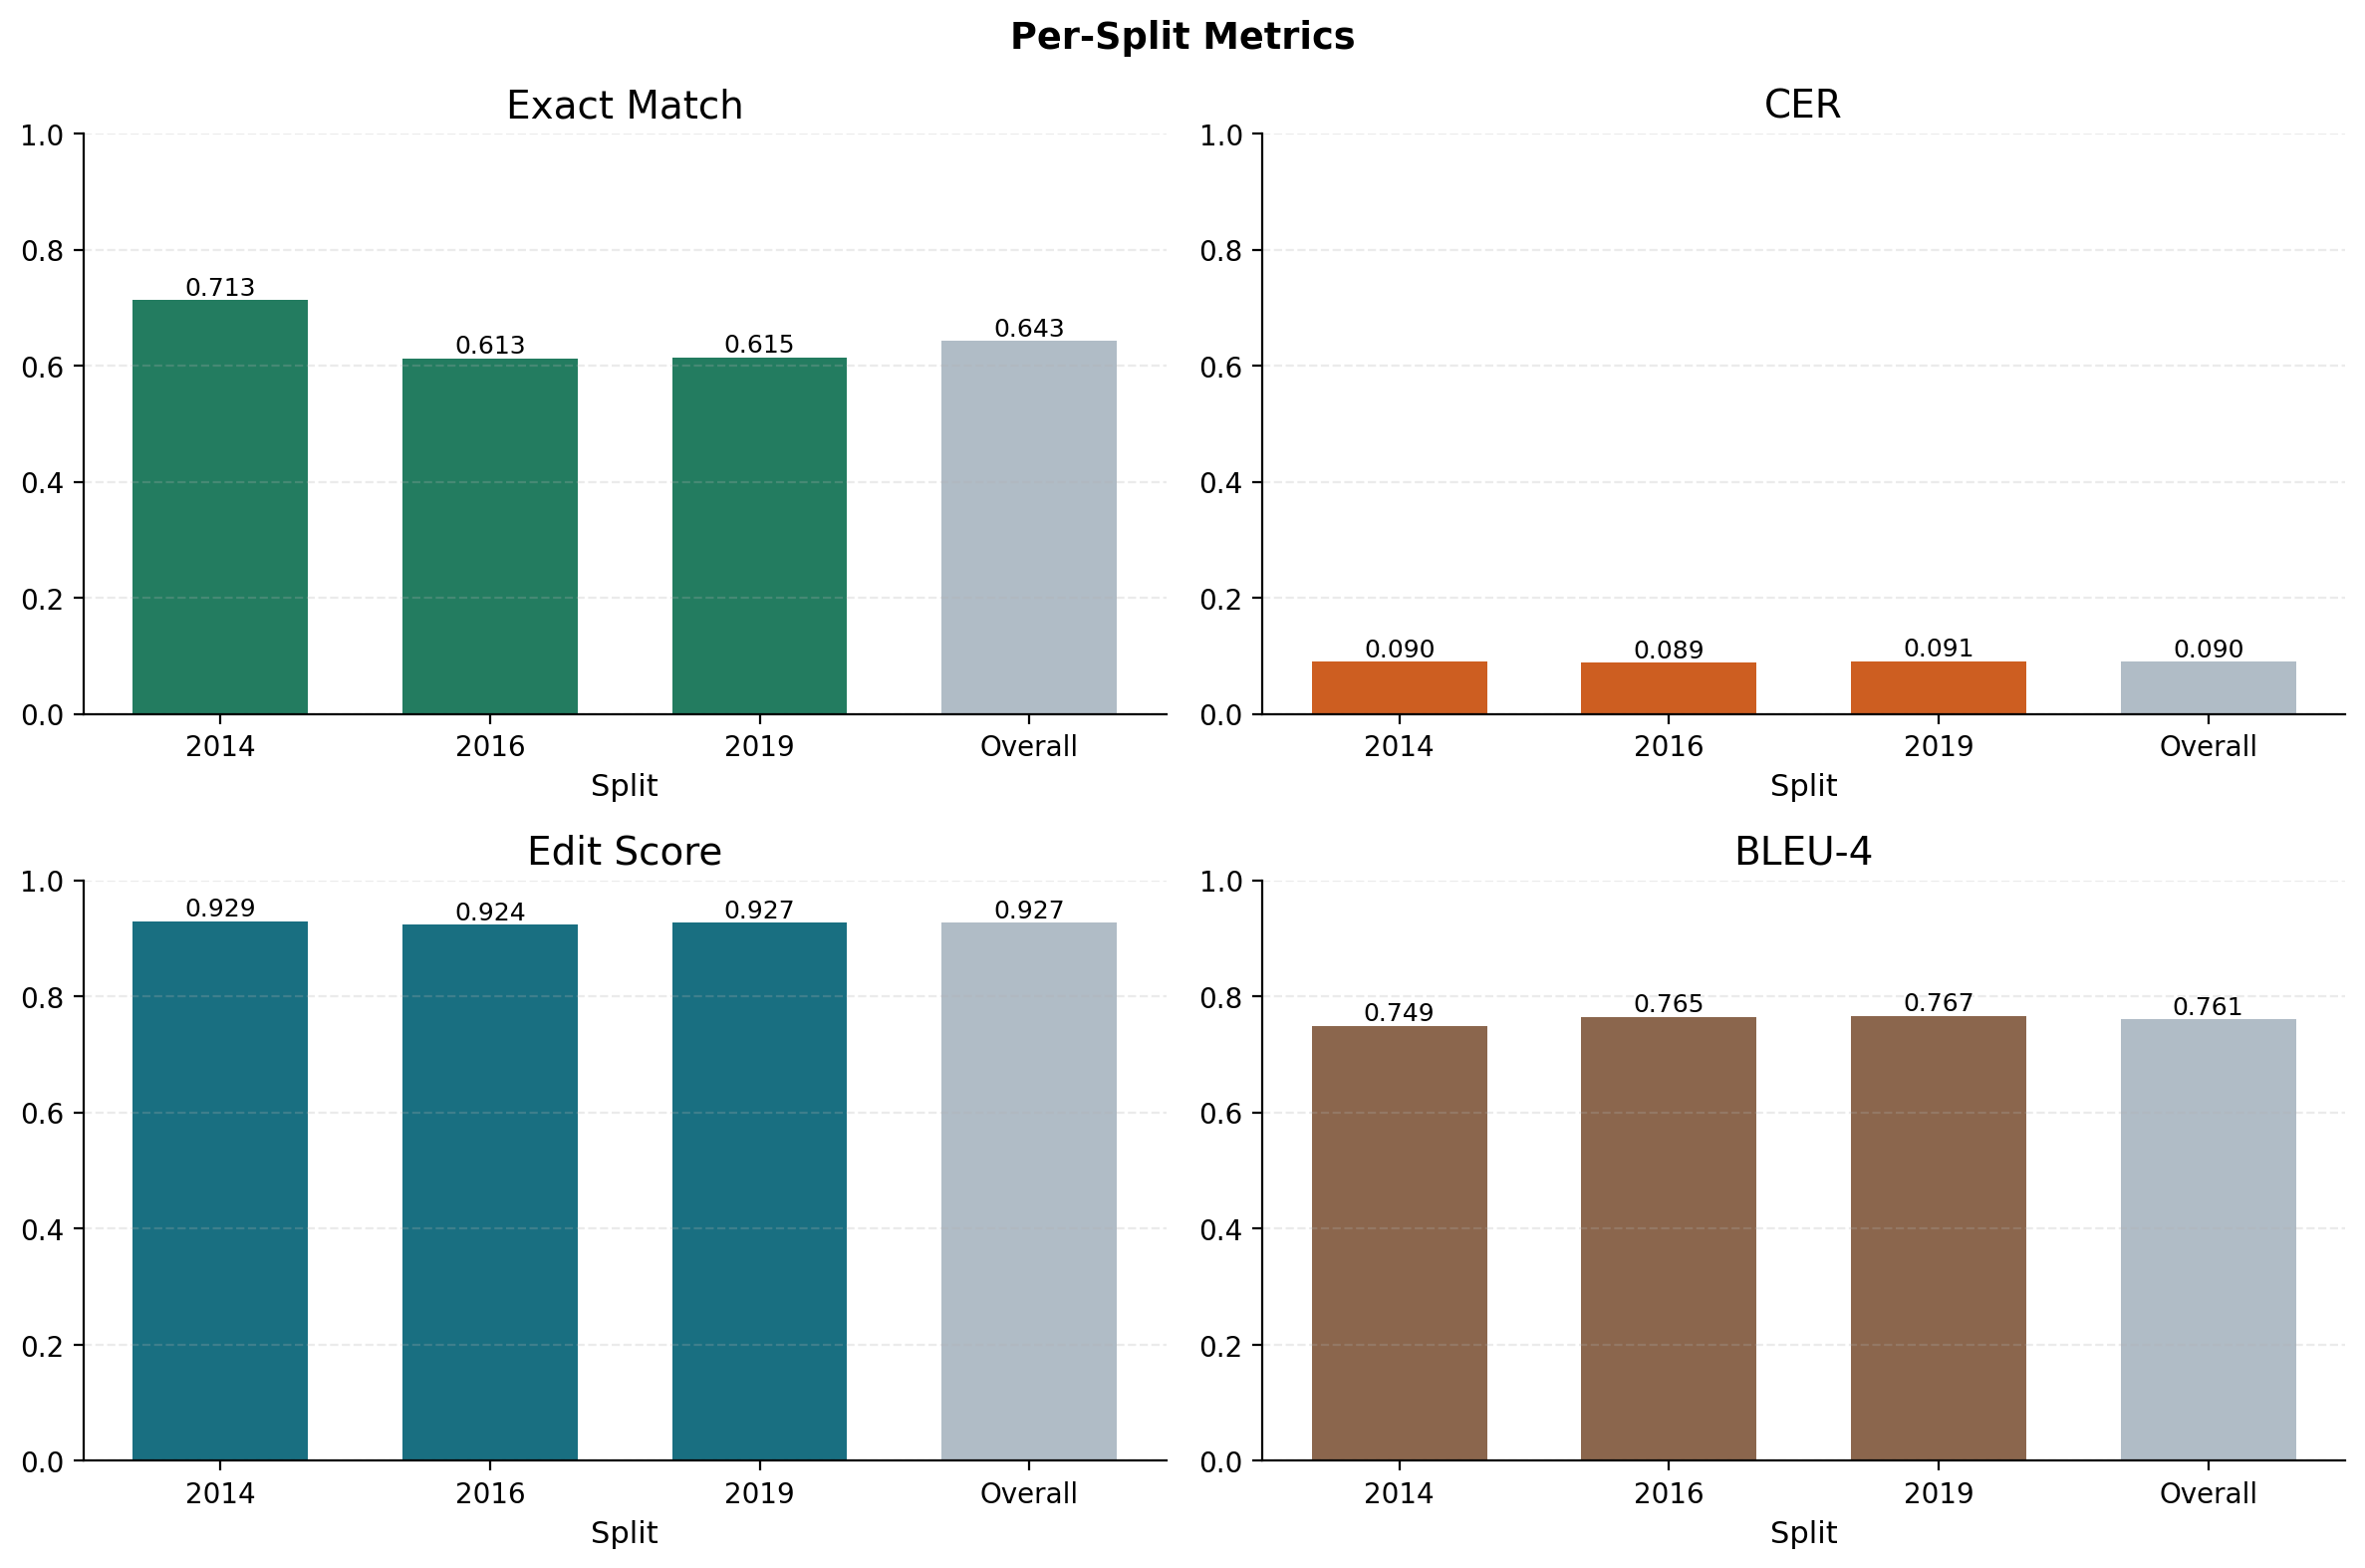

,task,exact_match_rate,avg_cer,avg_edit_score,avg_bleu4,avg_latency_s,num_samples
0,inference_only,0.389556,0.220228,0.824478,0.635974,0.825553,3332
1,lora_train_eval,0.643157,0.090063,0.926570,0.760845,1.721225,3332



=== Baseline vs LoRA comparison ===


,metric,baseline,lora,delta
0,exact_match_rate,0.389556,0.643157,0.253601
1,avg_cer,0.220228,0.090063,-0.130164
2,avg_edit_score,0.824478,0.926570,0.102093
3,avg_bleu4,0.635974,0.760845,0.124871
4,avg_latency_s,0.825553,1.721225,0.895672


In [5]:
from pathlib import Path
import json
import subprocess
import pandas as pd
import yaml
from IPython.display import Image, display


def resolve_results_dir(task: str) -> Path:
    config_path = Path('configs') / f'colab_{task}.yaml'
    cfg = yaml.safe_load(config_path.read_text(encoding='utf-8'))
    root = Path(cfg['output_dir'])
    if task == 'inference_only':
        return root / 'overall_results'
    return root / 'checkpoint-final' / 'overall_results'


def resolve_label(task: str) -> str:
    if task == 'inference_only':
        return 'base'
    if task == 'lora_train_eval':
        return 'lora'
    return task


def collect_experiments() -> list[tuple[str, Path, str]]:
    experiments = []
    for task in config_paths:
        label = resolve_label(task)
        results_dir = resolve_results_dir(task)
        experiments.append((task, results_dir, label))
    return experiments


def run_visualization_bundle(experiments: list[tuple[str, Path, str]]) -> None:
    cmd = ['bash', 'scripts/run_report_visualization.sh']
    for _, results_dir, label in experiments:
        cmd.append(f'{label}={results_dir}')
    if experiments:
        cmd.extend(['--reference-label', experiments[0][2]])
    subprocess.run(cmd, check=True)


def show_single_experiment_figures(task: str, results_dir: Path) -> dict:
    metrics = json.loads((results_dir / 'overall_metrics.json').read_text(encoding='utf-8'))
    print(f'\n=== {task} overall metrics ===')
    print(json.dumps(metrics, indent=2))

    fig_dir = results_dir / 'report_figures'
    for fig_path in sorted(fig_dir.glob('*.png')):
        print(f'\n[{task}] {fig_path.name}')
        display(Image(filename=str(fig_path)))

    return metrics


experiments = collect_experiments()
run_visualization_bundle(experiments)

summary_rows = []
metric_names = ['exact_match_rate', 'avg_cer', 'avg_edit_score', 'avg_bleu4', 'avg_latency_s', 'num_samples']
for task, results_dir, label in experiments:
    metrics = show_single_experiment_figures(task, results_dir)
    row = {'task': task, 'label': label}
    for metric_name in metric_names:
        row[metric_name] = metrics.get(metric_name)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

comparison_root = Path('outputs') / 'experiment_comparisons'
if len(experiments) >= 2 and comparison_root.exists():
    comparison_df = pd.read_csv(comparison_root / 'comparison_metrics.csv')
    print('\n=== Shared comparison metrics ===')
    display(comparison_df)

    for fig_name in ['overall_metric_comparison.png', 'per_split_metric_comparison.png', 'latency_comparison.png']:
        fig_path = comparison_root / fig_name
        if fig_path.exists():
            print(f'\n[comparison] {fig_name}')
            display(Image(filename=str(fig_path)))

    reference_label = experiments[0][2]
    for _, _, candidate_label in experiments[1:]:
        pairwise_dir = comparison_root / f'vs_{candidate_label}'
        if not pairwise_dir.exists():
            continue
        summary_path = pairwise_dir / 'pairwise_summary.json'
        if summary_path.exists():
            print(f'\n=== Pairwise summary: {reference_label} -> {candidate_label} ===')
            print(summary_path.read_text(encoding='utf-8'))
        for fig_path in sorted(pairwise_dir.glob('*.png')):
            print(f'\n[{reference_label} vs {candidate_label}] {fig_path.name}')
            display(Image(filename=str(fig_path)))
